In [3]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import altair as alt
import plotly.io as pio

In [12]:
df = pl.read_csv("../4_sep/churn_data.csv")
print(df)

shape: (7_043, 21)
┌────────────┬────────┬─────────────┬─────────┬───┬─────────────┬─────────────┬────────────┬───────┐
│ customerID ┆ gender ┆ SeniorCitiz ┆ Partner ┆ … ┆ PaymentMeth ┆ MonthlyChar ┆ TotalCharg ┆ Churn │
│ ---        ┆ ---    ┆ en          ┆ ---     ┆   ┆ od          ┆ ges         ┆ es         ┆ ---   │
│ str        ┆ str    ┆ ---         ┆ str     ┆   ┆ ---         ┆ ---         ┆ ---        ┆ str   │
│            ┆        ┆ i64         ┆         ┆   ┆ str         ┆ f64         ┆ f64        ┆       │
╞════════════╪════════╪═════════════╪═════════╪═══╪═════════════╪═════════════╪════════════╪═══════╡
│ 7590-VHVEG ┆ Female ┆ 0           ┆ Yes     ┆ … ┆ Electronic  ┆ 29.85       ┆ 29.85      ┆ No    │
│            ┆        ┆             ┆         ┆   ┆ check       ┆             ┆            ┆       │
│ 5575-GNVDE ┆ Male   ┆ 0           ┆ No      ┆ … ┆ Mailed      ┆ 56.95       ┆ 1889.5     ┆ No    │
│            ┆        ┆             ┆         ┆   ┆ check       ┆       

## General Customer Profile

In [26]:
# --- Calculating means ---
means = df["tenure", "MonthlyCharges", "TotalCharges"].mean()
print("Means: \n", means)
median = df["tenure", "MonthlyCharges", "TotalCharges"].median()
print("Median: \n",median)

modes = {
    "tenure": df["tenure"].value_counts().sort("count", descending=True)[0, "tenure"],
    "MonthlyCharges": df["MonthlyCharges"].value_counts().sort("count", descending=True)[0, "MonthlyCharges"],
    "TotalCharges": df["TotalCharges"].value_counts().sort("count", descending=True)[0, "TotalCharges"],
}
print("Modes:\n", modes)







Means: 
 shape: (1, 3)
┌───────────┬────────────────┬──────────────┐
│ tenure    ┆ MonthlyCharges ┆ TotalCharges │
│ ---       ┆ ---            ┆ ---          │
│ f64       ┆ f64            ┆ f64          │
╞═══════════╪════════════════╪══════════════╡
│ 32.371149 ┆ 64.761692      ┆ 2283.300441  │
└───────────┴────────────────┴──────────────┘
Median: 
 shape: (1, 3)
┌────────┬────────────────┬──────────────┐
│ tenure ┆ MonthlyCharges ┆ TotalCharges │
│ ---    ┆ ---            ┆ ---          │
│ f64    ┆ f64            ┆ f64          │
╞════════╪════════════════╪══════════════╡
│ 29.0   ┆ 70.35          ┆ 1397.475     │
└────────┴────────────────┴──────────────┘
Modes:
 {'tenure': 1, 'MonthlyCharges': 20.05, 'TotalCharges': None}


Considering the mean and median of tenure, I would say that customers tend a lot to stay for almost two years and a half. This begins to feel like a reliable and trustworthy relationship between customer and company. 

## Distribution visualization

In [ ]:
# --- Generating histograms ---

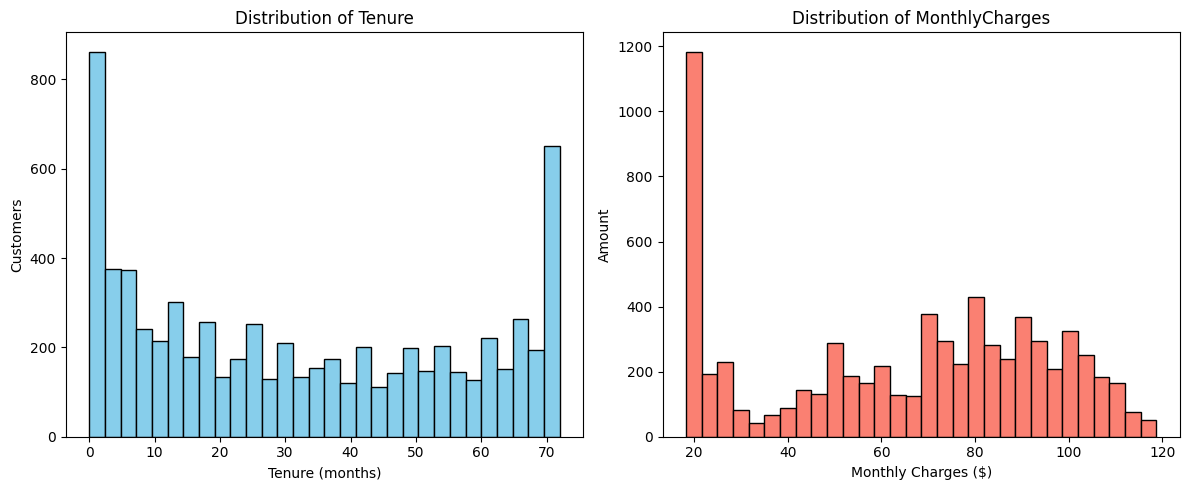

In [28]:
df_pd = df.select(["tenure", "MonthlyCharges"]).to_pandas()

plt.figure(figsize=(12,5))

# Tenure
plt.subplot(1,2,1)
plt.hist(df_pd["tenure"], bins=30, color="skyblue", edgecolor="black")
plt.title("Distribution of Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Customers")

# MonthlyCharges
plt.subplot(1,2,2)
plt.hist(df_pd["MonthlyCharges"], bins=30, color="salmon", edgecolor="black")
plt.title("Distribution of MonthlyCharges")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Amount")

plt.tight_layout()
plt.show()


It is clear that both Monthly Charges and Tenure are not symmetric but skewed to the right. 
It could be interesting to pay attention at the peaks for tennure. It seemes that there are a lot of customers, the majority I'd say, that do not stay longer than 5 months approximately. Howwver, the next peak is at 70+ months. This means that either customers use it as a quick visitation, or as a longer term plan. 

For the monthly charges, it seems that the company prefers to charge the most when the stay is shorter and in the first months, than when the customer has made a clear choice to stay and be more consistent. There is even a steady drop for the bigger drop, signaling the decrease in price over those months. 

## Segment Analysis

shape: (2, 3)
┌───────┬───────────────┬───────────────────────┐
│ Churn ┆ tenure_median ┆ MonthlyCharges_median │
│ ---   ┆ ---           ┆ ---                   │
│ str   ┆ f64           ┆ f64                   │
╞═══════╪═══════════════╪═══════════════════════╡
│ No    ┆ 38.0          ┆ 64.425                │
│ Yes   ┆ 10.0          ┆ 79.65                 │
└───────┴───────────────┴───────────────────────┘


<Figure size 600x500 with 0 Axes>

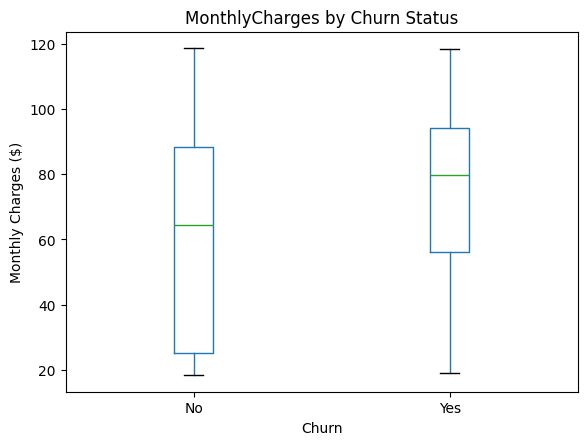

In [39]:
ctx = pl.SQLContext(population=df, eager=True)

medians_churn = ctx.execute(
    """
    SELECT
        Churn,
        MEDIAN(tenure) AS tenure_median,
        MEDIAN(MonthlyCharges) AS MonthlyCharges_median
    FROM population
    GROUP BY Churn
    """
)

print(medians_churn)


# Convert to pandas for plotting boxplots if needed
df_pd = df.select(["Churn", "MonthlyCharges"]).to_pandas()

plt.figure(figsize=(6,5))
df_pd.boxplot(column="MonthlyCharges", by="Churn", grid=False)
plt.title("MonthlyCharges by Churn Status")
plt.suptitle("")  # remove default title
plt.xlabel("Churn")
plt.ylabel("Monthly Charges ($)")
plt.show()




From the grouping by churning, it can be said that those who did not churn, had a median of 38 and a monthly charge median of 64. Comparing thr grouping of the customers that did churn, the latter stayed for less (a median of 10), having to pay even more. 

With the box plot we can get more insight about what really happens to the group as a whole, and not only the median. It seems that does who did not churn, had a lower monthly charge, as expected, but also had a bigger range of prices. However, even with that range, does who did churn had to pay significantly more, and their lowest pay was just below the median of the people who did not churn. 